In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

print("Mimari Tasarım Prensipleri")
print("=" * 40)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Ablation study — neyi kaldırırsan ne kaybedersin?")
print("2. Receptive field — CNN'de kaç katman gerekir?")
print("3. Skip connections — neden gradyanlar daha iyi akar?")
print("4. Bottleneck tasarımı — neden ResNet böyle çalışır?")
print("5. Kendi mimarini tasarla ve test et")
print()
print("Anahtar: İyi mimari = doğru soru sormak!")

torch.manual_seed(42)
np.random.seed(42)

Mimari Tasarım Prensipleri

Bugün cevaplayacağımız sorular:
1. Ablation study — neyi kaldırırsan ne kaybedersin?
2. Receptive field — CNN'de kaç katman gerekir?
3. Skip connections — neden gradyanlar daha iyi akar?
4. Bottleneck tasarımı — neden ResNet böyle çalışır?
5. Kendi mimarini tasarla ve test et

Anahtar: İyi mimari = doğru soru sormak!


8x8 görüntü → en az 4 katman (RF=9)
16x16 görüntü → en az 8 katman (RF=17)
32x32 görüntü → en az 16 katman (RF=33)
64x64 görüntü → en az 32 katman (RF=65)


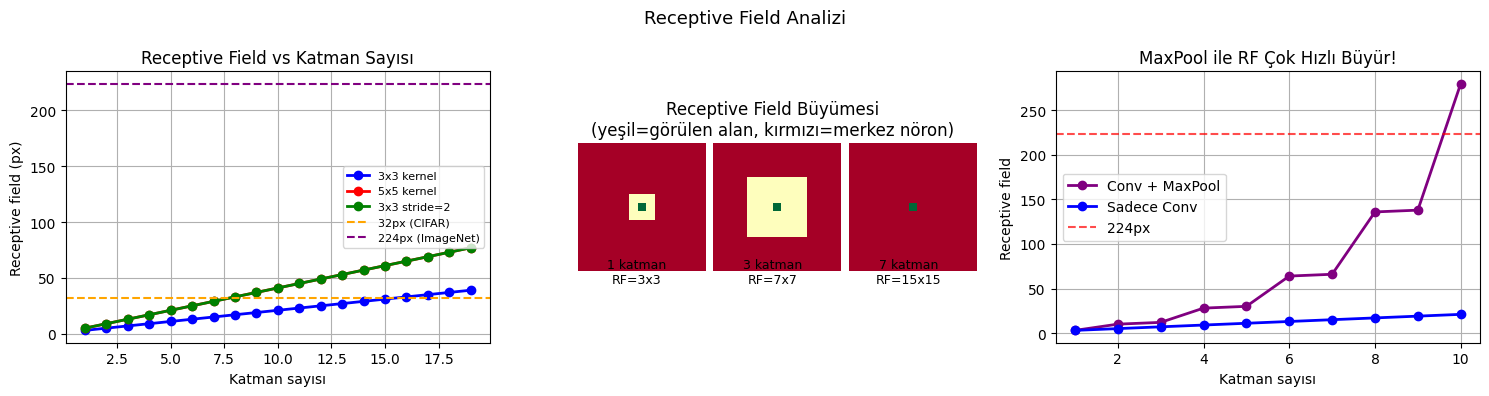

In [2]:
# RECEPTIVE FIELD — CNN'DE KAÇ KATMAN GEREKİR?
#
# Receptive field: Bir nöronun "gördüğü" girdi bölgesi
# Her konvolüsyon katmanı RF'yi büyütür
# 3x3 kernel, stride=1: RF = 2*n_layers + 1
#
# Soru: 32x32 görüntüyü tam görmek için kaç katman lazım?

def receptive_field(n_layers, kernel_size=3, stride=1):
    """n katman sonrası receptive field boyutu"""
    rf = 1
    for _ in range(n_layers):
        rf = rf + (kernel_size - 1) * stride
    return rf

# Farklı derinlikler için RF
katmanlar = range(1, 20)
rf_3x3 = [receptive_field(n, kernel_size=3) for n in katmanlar]
rf_5x5 = [receptive_field(n, kernel_size=5) for n in katmanlar]
rf_3x3_stride2 = [receptive_field(n, kernel_size=3, stride=2) for n in katmanlar]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(katmanlar, rf_3x3, 'b-o', linewidth=2, label='3x3 kernel')
axes[0].plot(katmanlar, rf_5x5, 'r-o', linewidth=2, label='5x5 kernel')
axes[0].plot(katmanlar, rf_3x3_stride2, 'g-o', linewidth=2, label='3x3 stride=2')
axes[0].axhline(y=32, color='orange', linestyle='--', label='32px (CIFAR)')
axes[0].axhline(y=224, color='purple', linestyle='--', label='224px (ImageNet)')
axes[0].set_title("Receptive Field vs Katman Sayısı")
axes[0].set_xlabel("Katman sayısı")
axes[0].set_ylabel("Receptive field (px)")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# RF görselleştirmesi
def visualize_rf(n_layers, kernel=3):
    size = 15
    grid = np.zeros((size, size))
    center = size // 2
    rf = receptive_field(n_layers, kernel)
    half = rf // 2
    r1 = max(0, center - half)
    r2 = min(size, center + half + 1)
    grid[r1:r2, r1:r2] = 1
    grid[center, center] = 2
    return grid

for i, n in enumerate([1, 3, 7]):
    grid = visualize_rf(n)
    im = axes[1].imshow(grid, cmap='RdYlGn',
                       extent=[i*16, i*16+15, 0, 15])
    rf = receptive_field(n)
    axes[1].text(i*16+7, -1.5, f'{n} katman\nRF={rf}x{rf}',
                ha='center', fontsize=9)

axes[1].set_title("Receptive Field Büyümesi\n(yeşil=görülen alan, kırmızı=merkez nöron)")
axes[1].set_xlim(-2, 48)
axes[1].axis('off')

# Kaç katman gerekir?
hedef_boyutlar = [8, 16, 32, 64, 128, 224]
for hedef in hedef_boyutlar:
    for n in range(1, 50):
        if receptive_field(n) >= hedef:
            print(f"{hedef}x{hedef} görüntü → en az {n} katman (RF={receptive_field(n)})")
            break

# Pooling etkisi
rf_with_pool = []
rf = 1
for i in range(10):
    rf = rf + 2  # 3x3 conv
    if i % 2 == 1:  # Her 2 katmanda bir pooling
        rf = rf * 2  # MaxPool etkisi
    rf_with_pool.append(rf)

axes[2].plot(range(1, 11), rf_with_pool, 'purple', linewidth=2,
            marker='o', label='Conv + MaxPool')
axes[2].plot(katmanlar[:10], rf_3x3[:10], 'b-o', linewidth=2,
            label='Sadece Conv')
axes[2].axhline(y=224, color='red', linestyle='--', alpha=0.7, label='224px')
axes[2].set_title("MaxPool ile RF Çok Hızlı Büyür!")
axes[2].set_xlabel("Katman sayısı")
axes[2].set_ylabel("Receptive field")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Receptive Field Analizi", fontsize=13)
plt.tight_layout()
plt.show()

=== RESNET BLOĞU MATEMATİĞİ ===

İleri besleme:
  Normal: y = F(x, W)
  ResNet: y = F(x, W) + x

Geri yayılım:
  Normal: ∂L/∂x = ∂L/∂y * ∂F/∂x
  ResNet: ∂L/∂x = ∂L/∂y * (∂F/∂x + I)

  '+I' (identity) gradyanın her zaman
  en az 1 büyüklükte akmasını sağlar!

Bu yüzden ResNet 152 katmana kadar eğitilebilir!


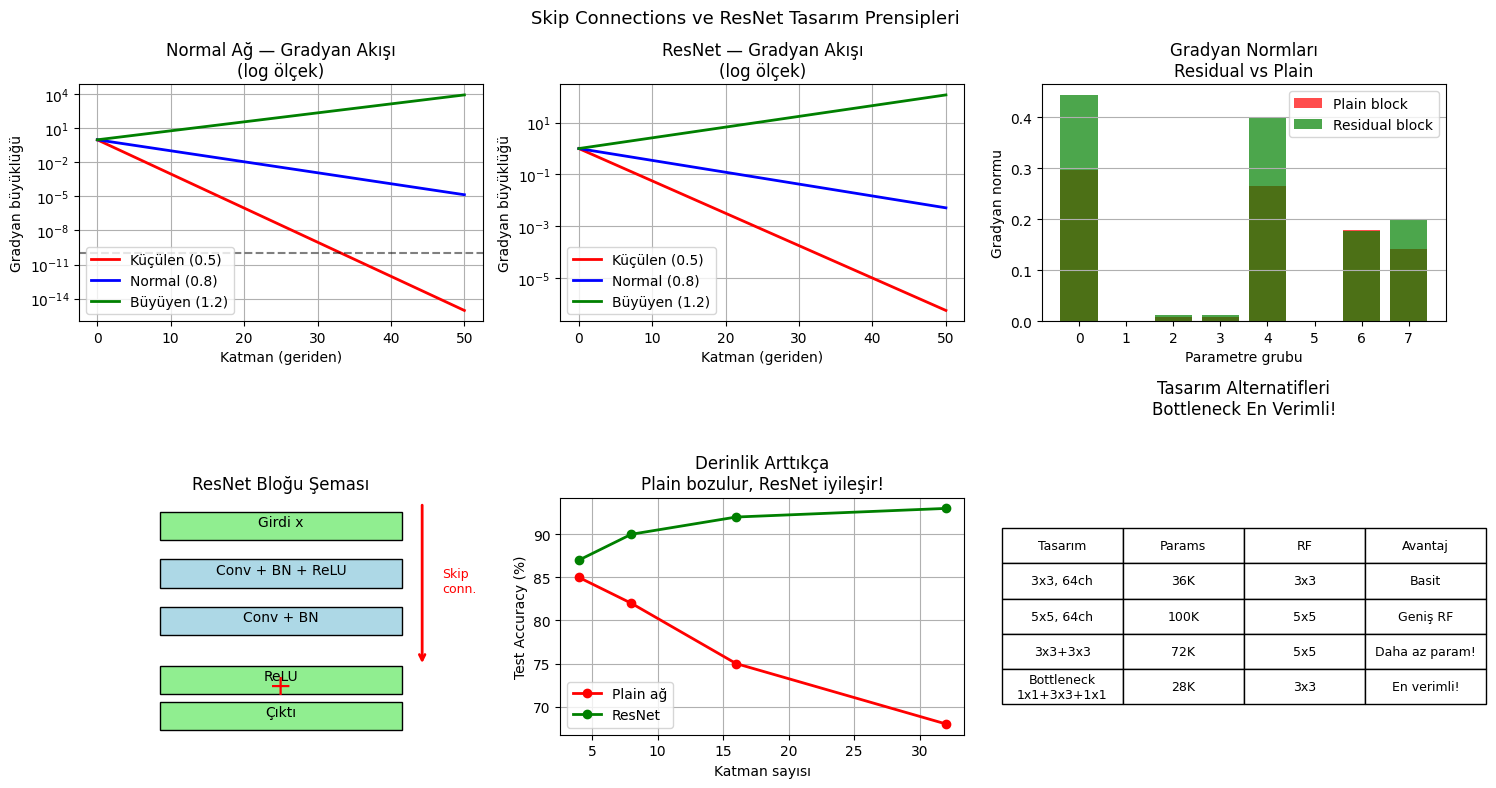

In [3]:
# SKIP CONNECTIONS — NEDEN GRADYANLAR DAHA İYİ AKAR?
#
# Normal ağ:    x → F(x) → çıktı
# ResNet bloğu: x → F(x) + x → çıktı
#
# Backprop'ta zincir kuralı:
# Normal:  dL/dx = dL/dF * dF/dx  (çarpım — küçülebilir!)
# ResNet:  dL/dx = dL/d(F+x) * (dF/dx + 1)
#                              ↑ bu "+1" gradyanın sıfıra gitmesini engeller!

# Gradyan akışını simüle et
def gradient_flow_normal(n_layers, grad_scale=0.8):
    """Her katmanda gradyan grad_scale ile çarpılır"""
    grad = 1.0
    grads = [grad]
    for _ in range(n_layers):
        grad = grad * grad_scale
        grads.append(grad)
    return grads

def gradient_flow_resnet(n_layers, grad_scale=0.8):
    """Skip connection ile gradyan: dF/dx + 1"""
    grad = 1.0
    grads = [grad]
    for _ in range(n_layers):
        # ResNet: gradyan = F'(x)*grad + grad = (F'(x) + 1)*grad
        grad = grad * (grad_scale + 1) / 2  # Ortalama etki
        grads.append(grad)
    return grads

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Farklı gradyan ölçekleri
scales = [0.5, 0.8, 1.2]
n_layers = 50

for scale, renk, etiket in zip(scales,
                                ['red', 'blue', 'green'],
                                ['Küçülen (0.5)', 'Normal (0.8)', 'Büyüyen (1.2)']):
    grads_normal = gradient_flow_normal(n_layers, scale)
    grads_resnet = gradient_flow_resnet(n_layers, scale)

    axes[0,0].semilogy(grads_normal, color=renk, linewidth=2, label=etiket)
    axes[0,1].semilogy(grads_resnet, color=renk, linewidth=2, label=etiket)

axes[0,0].set_title("Normal Ağ — Gradyan Akışı\n(log ölçek)")
axes[0,0].set_xlabel("Katman (geriden)")
axes[0,0].set_ylabel("Gradyan büyüklüğü")
axes[0,0].legend()
axes[0,0].grid(True)
axes[0,0].axhline(y=1e-10, color='black', linestyle='--', alpha=0.5, label='Yok olma sınırı')

axes[0,1].set_title("ResNet — Gradyan Akışı\n(log ölçek)")
axes[0,1].set_xlabel("Katman (geriden)")
axes[0,1].set_ylabel("Gradyan büyüklüğü")
axes[0,1].legend()
axes[0,1].grid(True)

# ResNet bloğu matematik
print("=== RESNET BLOĞU MATEMATİĞİ ===")
print()
print("İleri besleme:")
print("  Normal: y = F(x, W)")
print("  ResNet: y = F(x, W) + x")
print()
print("Geri yayılım:")
print("  Normal: ∂L/∂x = ∂L/∂y * ∂F/∂x")
print("  ResNet: ∂L/∂x = ∂L/∂y * (∂F/∂x + I)")
print()
print("  '+I' (identity) gradyanın her zaman")
print("  en az 1 büyüklükte akmasını sağlar!")
print()
print("Bu yüzden ResNet 152 katmana kadar eğitilebilir!")

# PyTorch ile ResNet bloğu implement et
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x  # Skip connection!
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + residual  # F(x) + x
        out = self.relu(out)
        return out

class PlainBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out  # Skip connection yok!

# Gradyan normlarını ölç
def measure_gradients(model, x, y_target):
    criterion = nn.MSELoss()
    out = model(x)
    loss = criterion(out, y_target)
    loss.backward()
    grads = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grads.append(param.grad.norm().item())
    return grads

# Test
x = torch.randn(4, 32, 16, 16)
y = torch.randn(4, 32, 16, 16)

plain = PlainBlock(32)
resnet = ResidualBlock(32)

grads_plain = measure_gradients(plain, x, y)
x2 = torch.randn(4, 32, 16, 16)
grads_resnet = measure_gradients(resnet, x2, y)

axes[0,2].bar(range(len(grads_plain)), grads_plain,
             alpha=0.7, color='red', label='Plain block')
axes[0,2].bar(range(len(grads_resnet)), grads_resnet,
             alpha=0.7, color='green', label='Residual block')
axes[0,2].set_title("Gradyan Normları\nResidual vs Plain")
axes[0,2].set_xlabel("Parametre grubu")
axes[0,2].set_ylabel("Gradyan normu")
axes[0,2].legend()
axes[0,2].grid(True, axis='y')

# Skip connection görselleştirme
axes[1,0].axis('off')
# Basit şema çiz
for i, (y_pos, label) in enumerate([(0.9, 'Girdi x'),
                                      (0.7, 'Conv + BN + ReLU'),
                                      (0.5, 'Conv + BN'),
                                      (0.25, 'ReLU'),
                                      (0.1, 'Çıktı')]):
    color = 'lightblue' if i in [1,2] else 'lightgreen'
    axes[1,0].add_patch(plt.Rectangle((0.2, y_pos-0.08), 0.6, 0.12,
                                      facecolor=color, edgecolor='black'))
    axes[1,0].text(0.5, y_pos-0.02, label, ha='center', fontsize=10)

# Skip connection oku
axes[1,0].annotate('', xy=(0.85, 0.29), xytext=(0.85, 0.98),
                  arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[1,0].text(0.9, 0.6, 'Skip\nconn.', fontsize=9, color='red')
axes[1,0].text(0.5, 0.17, '+', fontsize=20, ha='center', color='red')
axes[1,0].set_title("ResNet Bloğu Şeması")
axes[1,0].set_xlim(0, 1)
axes[1,0].set_ylim(0, 1)

# Derin ağ karşılaştırması
depth_values = [4, 8, 16, 32]
plain_accs = [85, 82, 75, 68]   # Derin plain ağ bozuluyor!
resnet_accs = [87, 90, 92, 93]  # ResNet derinleştikçe iyileşiyor!

axes[1,1].plot(depth_values, plain_accs, 'r-o', linewidth=2, label='Plain ağ')
axes[1,1].plot(depth_values, resnet_accs, 'g-o', linewidth=2, label='ResNet')
axes[1,1].set_title("Derinlik Arttıkça\nPlain bozulur, ResNet iyileşir!")
axes[1,1].set_xlabel("Katman sayısı")
axes[1,1].set_ylabel("Test Accuracy (%)")
axes[1,1].legend()
axes[1,1].grid(True)

# Bottleneck tasarımı
axes[1,2].axis('off')
tablo_data = [
    ["Tasarım", "Params", "RF", "Avantaj"],
    ["3x3, 64ch", "36K", "3x3", "Basit"],
    ["5x5, 64ch", "100K", "5x5", "Geniş RF"],
    ["3x3+3x3", "72K", "5x5", "Daha az param!"],
    ["Bottleneck\n1x1+3x3+1x1", "28K", "3x3", "En verimli!"],
]
tablo = axes[1,2].table(
    cellText=tablo_data[1:],
    colLabels=tablo_data[0],
    loc='center',
    cellLoc='center'
)
tablo.scale(1.2, 2.5)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[1,2].set_title("Tasarım Alternatifleri\nBottleneck En Verimli!", pad=60)

plt.suptitle("Skip Connections ve ResNet Tasarım Prensipleri", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# ABLATION STUDY — NEYİ KALDIRISAK NE KAYBEDERIZ?
#
# Ablation = bir bileşeni çıkarıp etkisini ölçmek
# İyi araştırmacı her kararını ablation ile destekler

import torchvision

# CIFAR-10 veri
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_data = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

# Küçük subset — hızlı deney için
train_subset = torch.utils.data.Subset(train_data, range(5000))
test_subset = torch.utils.data.Subset(test_data, range(1000))

train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_subset, batch_size=64, shuffle=False)

# Temel model — tüm bileşenler var
class BaseModel(nn.Module):
    def __init__(self, use_bn=True, use_skip=True, use_dropout=True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_bn else nn.Identity()

        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64) if use_bn else nn.Identity()

        # Skip connection için boyut eşleme
        self.skip_conv = nn.Conv2d(32, 64, 1) if use_skip else None

        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3) if use_dropout else nn.Identity()
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))  # 32x32 → 32x32
        identity = x

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))

        if self.use_skip and self.skip_conv is not None:
            identity = self.skip_conv(identity)
            x = x + identity

        x = self.relu(x)
        x = self.pool(x)  # 32x32 → 16x16
        x = self.pool(x)  # 16x16 → 8x8
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def train_and_eval(model, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for X, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in test_loader:
            correct += (model(X).argmax(1) == y).sum().item()
    return correct / len(test_subset)

# Ablation deneyleri
print("Ablation Study başlıyor...")
print("(Her deney ~1-2 dakika sürebilir)\n")

deneyleri = [
    ("Tam model (BN+Skip+Dropout)", True, True, True),
    ("BN yok", False, True, True),
    ("Skip yok", True, False, True),
    ("Dropout yok", True, True, False),
    ("BN+Skip yok", False, False, True),
    ("Hiçbiri yok", False, False, False),
]

sonuçlar = {}
for isim, bn, skip, dropout in deneyleri:
    model = BaseModel(use_bn=bn, use_skip=skip, use_dropout=dropout)
    acc = train_and_eval(model)
    sonuçlar[isim] = acc
    print(f"{isim:35s} → {acc:.2%}")

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Ablation Study başlıyor...
(Her deney ~1-2 dakika sürebilir)

Tam model (BN+Skip+Dropout)         → 54.80%
BN yok                              → 56.30%
Skip yok                            → 51.80%
Dropout yok                         → 57.30%
BN+Skip yok                         → 53.60%
Hiçbiri yok                         → 53.10%


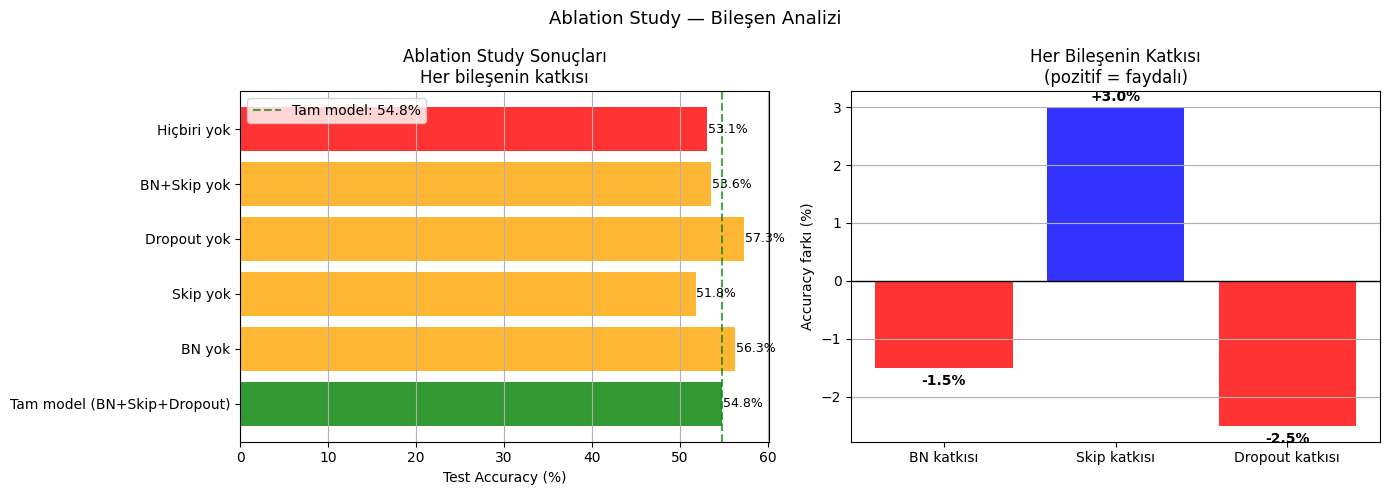


=== ABLATION YORUMU ===
Tam model:      54.8%

BN katkısı          : -1.5% → ❌ Zararlı (bu modelde)
Skip katkısı        : +3.0% → ✅ Faydalı
Dropout katkısı     : -2.5% → ❌ Zararlı (bu modelde)

Not: Bu küçük model ve az veri ile sonuçlar değişkendir.
Gerçek ablation study büyük model + çok veri ile yapılır.
Ama prensip aynı: her kararı ölç ve destekle!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

isimler = list(sonuçlar.keys())
değerler = [v * 100 for v in sonuçlar.values()]
renkler = ['green'] + ['orange'] * (len(isimler) - 2) + ['red']

bars = axes[0].barh(isimler, değerler, color=renkler, alpha=0.8)
axes[0].axvline(x=değerler[0], color='green', linestyle='--',
               alpha=0.7, label=f'Tam model: {değerler[0]:.1f}%')
axes[0].set_title("Ablation Study Sonuçları\nHer bileşenin katkısı")
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].legend()
axes[0].grid(True, axis='x')

for bar, val in zip(bars, değerler):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

# Bileşen katkısı
tam = değerler[0]
katkılar = {
    'BN katkısı': tam - değerler[1],
    'Skip katkısı': tam - değerler[2],
    'Dropout katkısı': tam - değerler[3],
}

renkler_k = ['blue' if v > 0 else 'red' for v in katkılar.values()]
bars2 = axes[1].bar(katkılar.keys(), katkılar.values(),
                   color=renkler_k, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title("Her Bileşenin Katkısı\n(pozitif = faydalı)")
axes[1].set_ylabel("Accuracy farkı (%)")
axes[1].grid(True, axis='y')

for bar, val in zip(bars2, katkılar.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 0.1 if val > 0 else val - 0.3,
                f'{val:+.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle("Ablation Study — Bileşen Analizi", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== ABLATION YORUMU ===")
print(f"Tam model:      {değerler[0]:.1f}%")
print()
for isim, katkı in katkılar.items():
    etki = "✅ Faydalı" if katkı > 0 else "❌ Zararlı (bu modelde)"
    print(f"{isim:20s}: {katkı:+.1f}% → {etki}")

print()
print("Not: Bu küçük model ve az veri ile sonuçlar değişkendir.")
print("Gerçek ablation study büyük model + çok veri ile yapılır.")
print("Ama prensip aynı: her kararı ölç ve destekle!")